In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
try:
    df = pd.read_csv('api_data.csv')
    print("✅ Data Loaded Successfully!")
    print(f"Total Rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")
except FileNotFoundError:
    print("Error: File not found. Please check the filename.")

✅ Data Loaded Successfully!
Total Rows: 500000
Columns: ['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']


In [ ]:
# 1. Check for missing values (Theory: Data Cleaning)
print("Missing Values per column:\n", df.isnull().sum())
print(df.columns.tolist())

# 2. Filter for "Late Bloomers"
# Theory: people Age > 18. 

late_bloomers = df[df['bio_age_17_'] > 18].copy()

print(f"\nFound {len(late_bloomers)} Late Bloomers (Age > 18).")

# 3. Group by District to find the "Hotspots"
district_counts = late_bloomers['district'].value_counts().reset_index()
district_counts.columns = ['District', 'Suspicious_Count']

print("\nTop 10 Districts with Suspicious Activity:")
print(district_counts.head(10))

Missing Values per column:
 date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64
['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

Found 140090 Late Bloomers (Age > 18).

Top 10 Districts with Suspicious Activity:
            District  Suspicious_Count
0               Pune              1062
1             Nashik               878
2              Thane               846
3          Ahmedabad               810
4           Thrissur               778
5             Mumbai               757
6          Hyderabad               737
7  North 24 Parganas               722
8             Nagpur               675
9            Jalgaon               666


C:\Users\Dell\AppData\Local\Temp\ipykernel_18400\475927552.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Suspicious_Count', y='District', data=top_10, palette='magma')


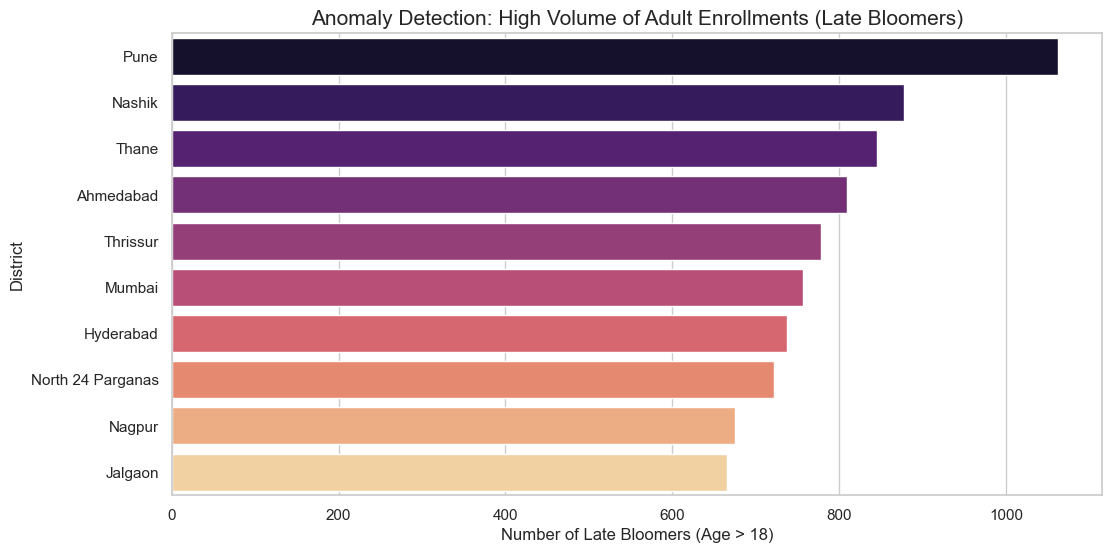

In [ ]:
# 4. Visualization
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

top_10 = district_counts.head(10)

sns.barplot(x='Suspicious_Count', y='District', data=top_10, palette='magma')

plt.title('Anomaly Detection: High Volume of Adult Enrollments (Late Bloomers)', fontsize=15)
plt.xlabel('Number of Late Bloomers (Age > 18)', fontsize=12)
plt.ylabel('District', fontsize=12)

plt.show()

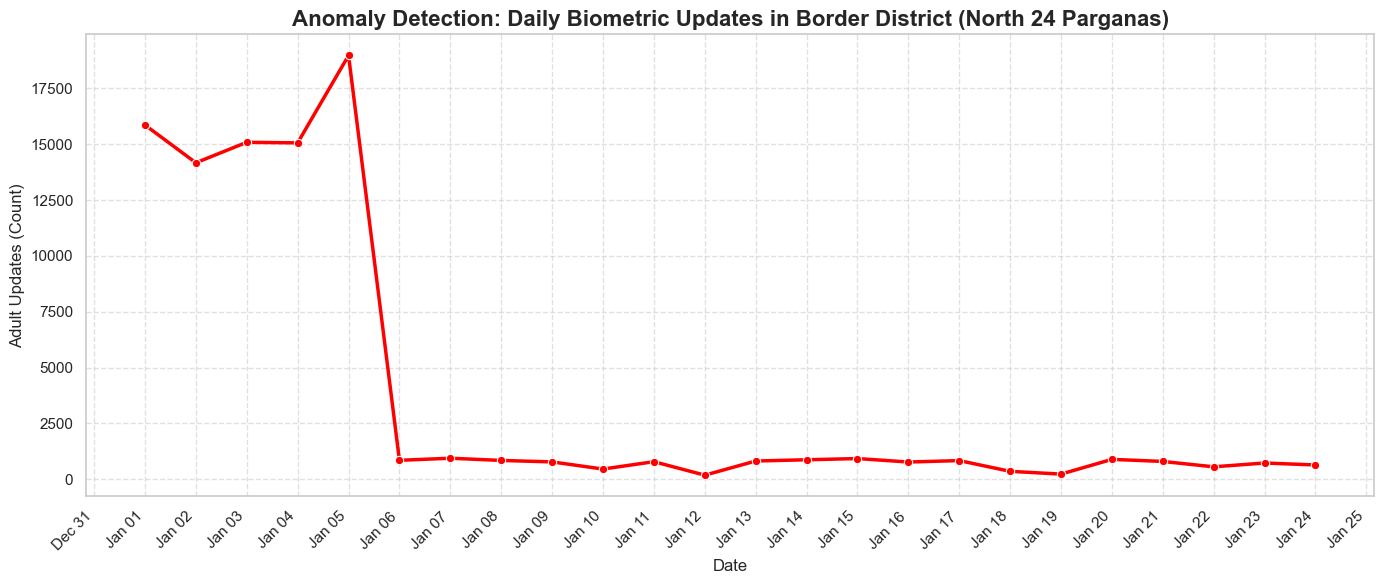

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

sns.lineplot(x='date', y='bio_age_17_', data=daily_trend, color='red', marker='o', linewidth=2.5)


ax = plt.gca()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))


ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))


plt.xticks(rotation=45, ha='right')


plt.title('Anomaly Detection: Daily Biometric Updates in Border District (North 24 Parganas)', fontsize=16, fontweight='bold')
plt.ylabel('Adult Updates (Count)', fontsize=12)
plt.xlabel('Date', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()  
plt.savefig('fraud_spike_graph.png')
plt.show()